# Tool outcome verification

**Recipe 29** · Level 3 (Intermediate) · Decision type: `Choice`

Classify recorded tool outcomes as complete, partial, failed, or unverifiable using the original request and observed evidence.

Sources:

- S02: [TypeSafe AI: Primitives (Questions)](https://docs.typesafe.ai/primitives)
- S03: [TypeSafe AI: Confidence](https://docs.typesafe.ai/confidence)
- S04: [TypeSafe AI: How to build with TypeSafe](https://docs.typesafe.ai/concepts/how-to-build-with-system-one)
- S06: [TypeSafe AI: Cookbooks](https://docs.typesafe.ai/cookbooks)

## What you will build

An agent asked a tool to do something -- write a file, send a batch of emails, deploy a canary, run a migration -- and the tool run left behind a record: what it reported, its exit code, a slice of its stdout and stderr, and the artefacts it listed. Python renders that record into the exact excerpt Jev reads; nothing the tool reported is held back from it. Jev then reads the request and the evidence together and names exactly one of four outcomes: `complete`, `partial`, `failed`, or `unverifiable`. Every one of the four goes through the same [confidence gate](../../docs/glossary.md#confidence-gate) first, with no exemption: below it, the run is sent to a review queue for a person to decide, with the reason `"confidence below the threshold"`. At or above the gate, `complete` is logged as an accepted handoff and `partial`/`failed` are both logged as a scheduled retry, naming which of the two it was; `unverifiable` is neither -- it says the evidence itself cannot settle the question, so it goes to the same review queue with its own reason, accepted by the gate but still a person's call. By the end you will have looked at the two hard cases this use case names up close -- a run that reports success with nothing behind it, and a run that reports success while its own output contradicts it -- and run an evaluation that chooses its one setting on `validation`, reports once on `test`, and scores both the raw judgment and the composed next step it produces.

## Setup and run mode

The notebook runs from its own folder with the standard library and `jev_cookbook` only. `get_backend(fixtures=...)` replays the 40 stored answers in `fixtures/responses.json` offline; setting `JEV_COOKBOOK_LIVE=1` (see the README) swaps in live calls to the same question definitions and changes nothing else. `run_header` states which mode ran, and every number below carries that mode with it.

In [1]:
from collections import Counter

from jev_cookbook import get_backend, load_helpers
from jev_cookbook.evaluation import (
    accuracy,
    confusion_matrix,
    evaluate_outcomes,
    per_class_metrics,
    select_confidence_threshold,
    selective_curve,
)
from jev_cookbook.fixtures import load_inputs, load_labels, responses_path, select_split
from jev_cookbook.simulation import ActionLog, ReviewQueue
from jev_cookbook.style import (
    apply_style,
    plot_answer_probabilities,
    plot_confusion_matrix,
    plot_risk_coverage,
    run_header,
    show_answer,
)

apply_style()
helpers = load_helpers()  # this recipe's helpers.py, loaded by path
examples = load_inputs()
labels = load_labels()
backend = get_backend(fixtures=responses_path())
questions = helpers.build_questions()
# N for the header is the number of examples the metrics are about: validation and test. This
# recipe has no train split; demo examples are shown but never scored.
scored = [e for e in examples if e.split not in ("train", "demo")]

offline = backend.mode in ("synthetic", "scripted")
check = " (a pipeline check, not a Jev result)" if offline else ""
# CONTRIBUTING.md section 2: "a number from the validation split is a selection step, not a
# result." This label does not depend on the run mode, unlike `check` above.
selection = " (a selection step, not a reported result)"

# Every one of the 40 examples in fixtures/ needs at most one request. This cache makes sure a
# run that is shown individually and later scored in its split is decided once, so the whole
# notebook makes exactly 40 requests in live mode, never more.
answered = {}


def decide(example):
    if example.id not in answered:
        answered[example.id] = backend.decide(helpers.build_state(example.fields), questions)[
            "outcome"
        ]
    return answered[example.id]


run_header(29, "Tool outcome verification", backend=backend, n_examples=len(scored))

Recipe 29: Tool outcome verification
Mode: offline replay of synthetic fixtures, pipeline check on a fixture sample of 38 examples
Metrics in this run are checks that the pipeline works. They are not Jev results.


## The state

Python renders the tool-run record -- the tool's name, its reported status, exit code, the artefacts it listed, and its stdout and stderr excerpts -- into the text Jev actually reads: `helpers.render_evidence`. The original request travels alongside it unchanged. The run's own identifier (`call_id`) stays in Python; it is never part of the state, so Jev never sees it and it is attached to the outcome afterwards. Nothing in the rendering is held back: whatever a stored answer's probabilities are based on is visible in the excerpt below, not only in the fixtures that generated it.

In [2]:
demo = {e.id: e for e in examples if e.split == "demo"}
no_evidence = demo["demo-01-no-evidence"]
print("request:", no_evidence.fields["request"])
print()
print(helpers.render_evidence(no_evidence.fields))

request: Email the renewal reminder to the 'expiring_7d' segment

Tool: send_email
Reported status: success
Exit code: 0
Artefacts listed: (none listed)
Stdout excerpt:
(no stdout captured)
Stderr excerpt:
(no stderr captured)


This is the first hard case this use case names: the tool reports `success`, with exit code `0`, but nothing else backs that up -- no stdout, no stderr, no artefact. The evidence cannot show the request was carried out, and it cannot show it was not, either. That is exactly what `unverifiable` is for, and exactly what tells it apart from `failed` below: `failed` needs a positive sign the request was *not* fulfilled, not merely an absence of signs that it was.

In [3]:
contradicts = demo["demo-02-contradicts"]
print("request:", contradicts.fields["request"])
print()
print(helpers.render_evidence(contradicts.fields))

request: Write the renewal letters to outbox/renewals_batch3.pdf

Tool: write_file
Reported status: success
Exit code: 0
Artefacts listed: (none listed)
Stdout excerpt:
(no stdout captured)
Stderr excerpt:
PermissionError: outbox/ is not writable


The second hard case: the tool again reports `success`, with exit code `0`, but its own stderr shows `PermissionError: outbox/ is not writable` and no artefact is listed at all. The reported status and the rest of the record disagree, and the description below says the rest of the record governs: this is `failed`, not `complete`, whatever the tool claims about itself. A rule that trusted the reported status alone would get this wrong every time it was asked; "Evaluation" scores exactly that trust, as a baseline, later in this notebook.

## The questions

There is one question, and it asks one thing: given the request and the evidence, which outcome best describes whether the request was fulfilled? A `Choice` fits because the four outcomes are exclusive and Jev should commit to exactly one. The option set is fixed to the four outcomes the use case names, built by Python in `helpers.OUTCOMES`, each defined so it does not overlap its neighbours: `unverifiable` means the evidence cannot settle the question either way, and `failed` means the evidence positively shows the request was not fulfilled -- a run with nothing to go on is the first, never the second.

Python lists the four outcomes in one fixed order for every run, with `complete` listed last rather than first. The reason is the cost of getting it wrong: a confidently wrong `complete` is logged as a finished handoff and leaves whatever actually happened -- a partial run, a failure, or a run nobody can verify -- standing as accepted work, with nobody told to look again. If a model leaned toward whichever option is listed first, listing `complete` last points that lean away from the costly mistake rather than toward it. Whether any model actually has that lean is not something this offline run can show either way: the raw answers below are probabilities written by hand for this fixture set, not a model's output, so how often they happen to land on the first-listed option is a property of the fixtures, not evidence about a lean. Only a recorded run could show that, so "Evaluation" below does not print a first-listed-option share as if it were such a check.

A `Choice` answer's `confidence` is the top probability rescaled by the number of options, `(p_max - 1/n) / (1 - 1/n)`: 0 when the top outcome has no more than an even quarter-share of the four, 1 when one outcome holds all the probability. See [TypeSafe AI: Confidence](https://docs.typesafe.ai/confidence) (S03) for the published formula. A low confidence here does not mean the evidence is unreadable; it means the top outcome did not pull far ahead of an even split across the four.

In [4]:
outcome_question = questions["outcome"]
print(outcome_question.instructions)
for name, description in outcome_question.criteria.items():
    print(f"  {name:14s} {description}")

An agent asked a tool to carry out the request. Given the request and the evidence the tool run reports, which outcome best describes whether the request was fulfilled? Judge from the evidence as a whole, not from the reported status alone.
  unverifiable   The evidence does not establish whether the request was carried out or not, either way. It may be missing, too thin to judge, or simply not about what the request actually asked for. This is different from failed: nothing here shows the request was NOT fulfilled, there just is not enough to show that it was.
  failed         The evidence shows the request was not fulfilled: an error message, a wrong or missing artefact, or an exit status that contradicts what the tool reported. This holds even when the tool's own reported status says the run succeeded -- a reported status is not itself evidence, and the rest of the record governs when it disagrees with it.
  partial        The evidence shows some, but not all, of the request was car

## One answer up close

Before any aggregate number, look at the two hard cases above answered in full, each with the chosen outcome, a probability for every outcome, the `confidence` explained above, and a [`provenance`](../../docs/glossary.md#provenance) line -- here always `synthetic`, since nothing in this recipe's fixtures came from a real call.

Choice: unverifiable (confidence 0.57)
  unverifiable  0.68  ##############
  failed        0.11  ##
  partial       0.11  ##
  complete      0.11  ##
Provenance: synthetic


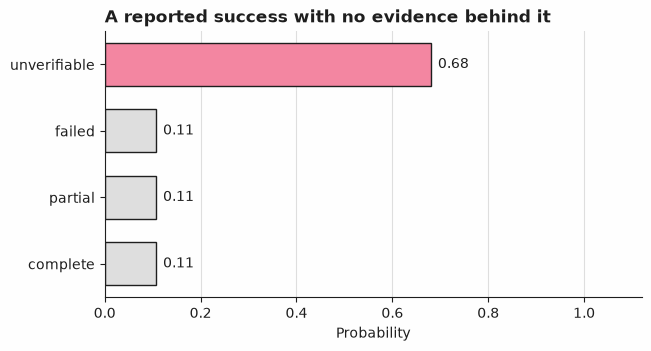

In [5]:
no_evidence_answer = decide(no_evidence)
show_answer(no_evidence_answer)
plot_answer_probabilities(no_evidence_answer, title="A reported success with no evidence behind it")

The stored answer calls this `unverifiable` at confidence 0.57. This demo run carries no [**gold label**](../../docs/glossary.md#gold-label) -- the correct outcome, written into the fixtures by whoever built them, never by Jev, used only to score an answer after the fact -- because demo examples are never scored; the identical pattern recurs, scored, in `validation` and `test` below.

Choice: complete (confidence 0.60)
  complete      0.70  ##############
  unverifiable  0.10  ##
  failed        0.10  ##
  partial       0.10  ##
Provenance: synthetic


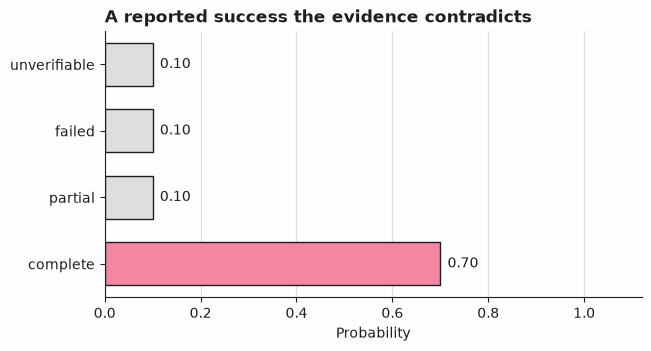

In [6]:
contradicts_answer = decide(contradicts)
show_answer(contradicts_answer)
plot_answer_probabilities(contradicts_answer, title="A reported success the evidence contradicts")

The stored answer here calls this `complete`, confidently (0.60): it reads the reported status instead of the stderr beneath it. This is a demo run, so nothing acts on it, but the identical mistake, scored, is exactly what "Evaluation" finds on `test` below -- the costly error this recipe is built to show.

## Python's part

Jev supplies the judgment; what happens with it is code. `helpers.classify` gates every outcome the same way, with no exemption: an answer below the confidence threshold goes to a `ReviewQueue` with the reason `"confidence below the threshold"`, whatever outcome it names. An answer at or above the threshold is accepted, and what Python does next depends only on which outcome it is: `complete` is logged to an `ActionLog` as `"handoff accepted"`; `partial` and `failed` are both logged as `"retry scheduled"`, with a reason naming which of the two it was; `unverifiable` is logged to the *same* `ReviewQueue` instead, with its own reason, because it answers "we cannot tell" rather than the question that was asked -- accepted by the gate, not rejected for low confidence, but still a person's decision either way.

CONTRIBUTING.md section 4's no-gate exemption is for a fallback that records no action and, when wrong, costs nothing beyond the missed item itself. `complete` fails both parts: choosing it records a finished handoff in the `ActionLog`, and a wrong `complete` leaves a run that was really `partial`, `failed`, or `unverifiable` standing as done, with nobody told to look again. That is why `complete` is gated here exactly like every other outcome, with no exemption claimed for it.

In [7]:
val_examples = select_split(examples, "validation")
val_answers = [decide(e) for e in val_examples]
val_gold = [labels[e.id] for e in val_examples]
val_correct = [a.choice == g for a, g in zip(val_answers, val_gold, strict=True)]
val_confidence = [a.confidence for a in val_answers]
threshold = select_confidence_threshold(val_correct, val_confidence, target_accuracy=1.0)
print(f"chosen threshold, frozen from here on: {threshold:.4f}{selection}{check}")

demo_actions, demo_queue = ActionLog(), ReviewQueue()
for shown_id, shown_example, shown_answer in (
    ("demo-01-no-evidence", no_evidence, no_evidence_answer),
    ("demo-02-contradicts", contradicts, contradicts_answer),
):
    outcome = helpers.classify(
        shown_example.fields["call_id"],
        shown_answer,
        threshold,
        actions=demo_actions,
        queue=demo_queue,
    )
    action = f" ({outcome.action})" if outcome.action else ""
    print(
        f"{shown_id}: {shown_answer.choice} at confidence {shown_answer.confidence:.2f} "
        f"-> {outcome.outcome}{action} [{outcome.reason}]"
    )

chosen threshold, frozen from here on: 0.4667 (a selection step, not a reported result) (a pipeline check, not a Jev result)
demo-01-no-evidence: unverifiable at confidence 0.57 -> unverifiable [evidence does not establish the outcome]
demo-02-contradicts: complete at confidence 0.60 -> complete (handoff accepted) [confident complete]


## Evaluation

The threshold was chosen and frozen above, on `validation`. Every outcome goes through the same gate: whether `classify` accepts an answer at all is exactly `confidence >= threshold`, nothing else. An accepted answer is not automatically a run this evaluation counts as *answered*, though: `classify` reports `unverifiable` as a deferral, not a result -- naming it is itself saying the question cannot be settled -- so CONTRIBUTING.md section 4 part (a) counts it toward review, never toward [coverage](../../docs/glossary.md#coverage), however confidently Jev named it. `helpers.accepted_and_correct` builds the two arrays [`jev_cookbook.evaluation.evaluate_outcomes`](../../docs/evaluation.md) needs for exactly that split: **coverage** is the fraction of runs `classify` reports with `complete`, `partial`, or `failed`, and among those, **accuracy** is the fraction right and **[risk](../../docs/glossary.md#risk)** is its complement, `1 - accuracy`.

This recipe's two-stage composition means per-question correctness is not the only thing worth scoring: `helpers.next_step_agreement` compares the *next step the system actually took* -- `"handoff accepted"`, `"retry scheduled"`, or `"review"` -- against the next step `helpers.NEXT_STEP` names for the **true** gold label, ignoring what Jev answered. This is the task-level metric: not "did Jev name the right outcome" but "did the composed system end up doing the right thing". In an offline run every `test` number here is a check that the pipeline works, and it says so; every `validation` number, in every run mode, is a selection step *and* a pipeline check, which is why it carries both labels.

In [8]:
def decide_split(split_examples, split_answers):
    actions, queue = ActionLog(), ReviewQueue()
    outcomes = [
        helpers.classify(e.fields["call_id"], a, threshold, actions=actions, queue=queue)
        for e, a in zip(split_examples, split_answers, strict=True)
    ]
    return outcomes, actions, queue


def split_metrics(split_examples, split_answers, split_gold, outcomes):
    gold_by_call = {e.fields["call_id"]: g for e, g in zip(split_examples, split_gold, strict=True)}
    accepted, correct = helpers.accepted_and_correct(outcomes, gold_by_call)
    outcomes_result = evaluate_outcomes(accepted, correct)
    agreement = helpers.next_step_agreement(outcomes, gold_by_call)
    return outcomes_result, agreement


def show_log(name, actions, queue):
    print(f"{name} action log: {len(actions)} entries{check}")
    for kind, n in sorted(Counter(e["kind"] for e in actions.to_dicts()).items()):
        executed = {e["executed"] for e in actions.by_kind(kind)}
        print(f"  {kind:20s} {n}  executed={executed}")
    print(f"{name} review queue: {len(queue)} entries{check}")
    for reason, n in sorted(Counter(i["reason"] for i in queue.to_dicts()).items()):
        print(f"  {reason:38s} {n}")
    # ActionLog and ReviewQueue are both append-only (seq / id assigned at submission time),
    # so to_dicts() is already in submission order by construction -- asserted here, not only
    # assumed, so a future change to either class that broke this would fail loudly.
    action_seq = [e["seq"] for e in actions.to_dicts()]
    queue_ids = [i["id"] for i in queue.to_dicts()]
    assert action_seq == sorted(action_seq), "action log is not in submission order"
    assert queue_ids == sorted(queue_ids), "review queue is not in submission order"


val_outcomes, val_actions, val_queue = decide_split(val_examples, val_answers)
val_result, val_agreement = split_metrics(val_examples, val_answers, val_gold, val_outcomes)

print(f"validation, {len(val_examples)} examples{selection}{check}")
print(f"accuracy of the raw choice: {accuracy(val_gold, val_answers):.4f}{selection}{check}")
print(
    f"answered (coverage): {val_result.n_answered} of {val_result.n_total} "
    f"(coverage {val_result.coverage:.4f}){selection}{check}"
)
print(f"accuracy among those answered: {val_result.accuracy:.4f}{selection}{check}")
print(f"risk among those answered: {val_result.risk:.4f}{selection}{check}")
print(f"next-step agreement with gold: {val_agreement:.4f}{selection}{check}")
show_log("validation", val_actions, val_queue)

validation, 19 examples (a selection step, not a reported result) (a pipeline check, not a Jev result)
accuracy of the raw choice: 0.8947 (a selection step, not a reported result) (a pipeline check, not a Jev result)
answered (coverage): 10 of 19 (coverage 0.5263) (a selection step, not a reported result) (a pipeline check, not a Jev result)
accuracy among those answered: 1.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
risk among those answered: 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
next-step agreement with gold: 0.7368 (a selection step, not a reported result) (a pipeline check, not a Jev result)
validation action log: 10 entries (a pipeline check, not a Jev result)
  handoff accepted     4  executed={False}
  retry scheduled      6  executed={False}
validation review queue: 9 entries (a pipeline check, not a Jev result)
  confidence below the threshold         7
  evidence does not establish the out

10 of the 19 validation runs clear the confidence gate and name one of the two actionable outcomes (`complete`, or `partial`/`failed`); accuracy and risk among those 10 are perfect, by construction, since `select_confidence_threshold(target_accuracy=1.0)` chose the lowest threshold with perfect accuracy among the gate-accepted answers. 9 runs go to the review queue: 7 for low confidence, and 2 confident `unverifiable` runs that the gate accepts but `accepted_and_correct` still marks not-accepted, because naming `unverifiable` is itself a deferral, whatever its confidence. The next-step agreement, 0.7368 (14 of 19), is lower than that -- every one of the 5 disagreements here is the gate being cautious about a run gold would have let through (a `complete`, `partial`, or `failed` run sent to review for low confidence instead of acted on), not a wrong action: a coverage cost, not a mistake.

test, 19 examples (a pipeline check, not a Jev result)
accuracy of the raw choice: 0.8947 (a pipeline check, not a Jev result)
answered (coverage): 10 of 19 (coverage 0.5263) (a pipeline check, not a Jev result)
accuracy among those answered: 0.9000 (a pipeline check, not a Jev result)
risk among those answered: 0.1000 (a pipeline check, not a Jev result)
next-step agreement with gold: 0.7368 (a pipeline check, not a Jev result)
test action log: 10 entries (a pipeline check, not a Jev result)
  handoff accepted     5  executed={False}
  retry scheduled      5  executed={False}
test review queue: 9 entries (a pipeline check, not a Jev result)
  confidence below the threshold         7
  evidence does not establish the outcome 2
frozen gate from above: 0.4667 (a pipeline check, not a Jev result)
Test confusion matrix, gold rows by predicted columns (a pipeline check, not a Jev result):
  predicted ->       unverifiable        failed       partial      complete (a pipeline check, not a Je

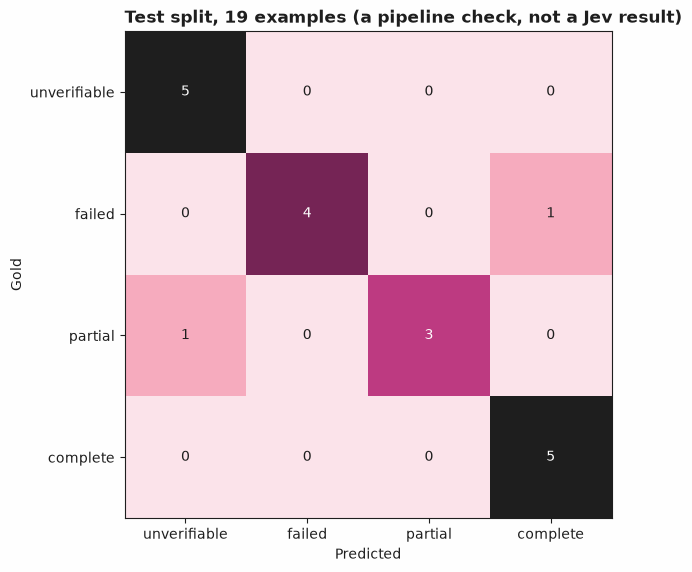

In [9]:
test_examples = select_split(examples, "test")
test_answers = [decide(e) for e in test_examples]
test_gold = [labels[e.id] for e in test_examples]

test_outcomes, test_actions, test_queue = decide_split(test_examples, test_answers)
test_result, test_agreement = split_metrics(test_examples, test_answers, test_gold, test_outcomes)

print(f"test, {len(test_examples)} examples{check}")
print(f"accuracy of the raw choice: {accuracy(test_gold, test_answers):.4f}{check}")
print(
    f"answered (coverage): {test_result.n_answered} of {test_result.n_total} "
    f"(coverage {test_result.coverage:.4f}){check}"
)
print(f"accuracy among those answered: {test_result.accuracy:.4f}{check}")
print(f"risk among those answered: {test_result.risk:.4f}{check}")
print(f"next-step agreement with gold: {test_agreement:.4f}{check}")
show_log("test", test_actions, test_queue)
print(f"frozen gate from above: {threshold:.4f}{check}")

matrix = confusion_matrix(test_gold, test_answers, labels=list(helpers.OUTCOMES))
width = max(len(label) for label in matrix.labels)
leader_width = max(width + len("gold "), len("predicted ->"))
header = "  ".join(f"{label:>{width}s}" for label in matrix.labels)
print(f"Test confusion matrix, gold rows by predicted columns{check}:")
print(f"  {'predicted ->':<{leader_width}s}  {header}{check}")
for gold_label, row in zip(matrix.labels, matrix.matrix.tolist(), strict=True):
    counts = "  ".join(f"{count:{width}d}" for count in row)
    leader = f"gold {gold_label:<{width}s}"
    print(f"  {leader:<{leader_width}s}  {counts}{check}")
plot_confusion_matrix(matrix, title=f"Test split, {len(test_examples)} examples{check}")

Risk is `0.1000` here, not `0.0000` as on `validation`: of the 10 test runs that clear the gate and name an actionable outcome, 1 is wrong -- `t-failed-05-contradicts`, the scored twin of the "contradicts" hard case shown up close above. It reports `success`, its stderr shows `PermissionError: outbox/ is not writable`, and the stored answer still calls it `complete`, confidently (0.67, comfortably above the 0.4667 gate): a false `complete`, logged to the action log as a finished handoff, with the genuine failure left standing. The next-step agreement, 0.7368 again, is made of two different kinds of disagreement this time: 4 of the 5 are the same conservative gating as on `validation` (a run gold would have let through, sent to review instead), and 1 -- this exact run -- is the costly mistake itself: the system's actual next step, `"handoff accepted"`, is not merely more cautious than gold's `"retry scheduled"`, it is the wrong thing done.

**`unverifiable` on its own.** It is the first-listed option (see "The questions" above). The raw choice names it 5 of 19 times on `validation` and 6 of 19 times on `test`, but that count says nothing about any model's lean toward the first-listed option: these are hand-written fixture probabilities, not a model's answers, so no share computed from them is a check for that. Every run the raw choice calls `unverifiable` is excluded from coverage, whatever its confidence, but most of that exclusion is already the confidence gate's doing: only 2 of the 5 `unverifiable` answers on `validation`, and 2 of the 6 on `test`, clear the gate at all (the review-queue breakdown above shows exactly 2 "evidence does not establish the outcome" entries on each split); the rest are already sent to review for low confidence before `classify` ever reaches the `unverifiable` branch. So the rule's own incremental cost, on top of what the confidence gate alone would have excluded, is those 2 runs per split, not the full 5 or 6. It also absorbs one gold class on each split: `v-partial-05-wrong` and `t-partial-04-wrong` are both genuinely `partial` -- the evidence shows some, not all, of the work done -- but the stored answer hedges to `unverifiable` instead of reading it, at a confidence low enough (0.30, 0.35) that the gate would have sent both to review anyway. The confusion matrix above shows this directly: row `partial`, column `unverifiable` holds a `1` on `test` (and the equivalent row on `validation`, not shown above, holds the same).

In [10]:
print(f"Test runs the raw choice got wrong, and what Python did with them{check}:")
for example, answer, gold, outcome in zip(
    test_examples, test_answers, test_gold, test_outcomes, strict=True
):
    if answer.choice != gold:
        print(
            f"  {example.id}: gold {gold}, answered {answer.choice} "
            f"(confidence {answer.confidence:.2f}) -> {outcome.outcome} [{outcome.reason}]"
        )

Test runs the raw choice got wrong, and what Python did with them (a pipeline check, not a Jev result):
  t-partial-04-wrong: gold partial, answered unverifiable (confidence 0.13) -> review [confidence below the threshold]
  t-failed-05-contradicts: gold failed, answered complete (confidence 0.67) -> complete [confident complete]


The cell above is why the rule is not enough on its own: a wrong answer with a high confidence passes the threshold, and a run that reports success can sit right on top of evidence that contradicts it. The fixtures include such cases on purpose, and a recipe's evaluation should find them rather than average them away.

For each outcome, [**precision**](../../docs/glossary.md#precision) is the fraction of the raw choice's calls of that outcome that were actually right, and [**recall**](../../docs/glossary.md#recall) is the fraction of that outcome's real `test` runs the raw choice found at all; [**F1**](../../docs/glossary.md#f1) is their harmonic mean, and [**support**](../../docs/glossary.md#support) is how many `test` runs actually carry that gold label.

In [11]:
per_class = per_class_metrics(test_gold, test_answers, labels=list(helpers.OUTCOMES))
for outcome, counts in per_class.items():
    print(
        f"{outcome:14s} precision {counts.precision:.3f}  recall {counts.recall:.3f}  "
        f"f1 {counts.f1:.3f}  support {counts.support}{check}"
    )

unverifiable   precision 0.833  recall 1.000  f1 0.909  support 5 (a pipeline check, not a Jev result)
failed         precision 1.000  recall 0.800  f1 0.889  support 5 (a pipeline check, not a Jev result)
partial        precision 1.000  recall 0.750  f1 0.857  support 4 (a pipeline check, not a Jev result)
complete       precision 0.833  recall 1.000  f1 0.909  support 5 (a pipeline check, not a Jev result)


One baseline with no judgment about the evidence at all: `helpers.self_report_baseline` trusts the tool's own reported status literally (`"success"` -> `complete`, `"failure"` -> `failed`, `"partial_success"` -> `partial`, anything else -> `unverifiable`).

In [12]:
self_report_val = [helpers.self_report_baseline(e.fields["reported_status"]) for e in val_examples]
self_report_test = [
    helpers.self_report_baseline(e.fields["reported_status"]) for e in test_examples
]
print(
    f"self-report baseline accuracy, validation: "
    f"{accuracy(val_gold, self_report_val):.4f}{selection}{check}"
)
print(f"self-report baseline accuracy, test: {accuracy(test_gold, self_report_test):.4f}{check}")
print(f"raw choice accuracy, test (for comparison): {accuracy(test_gold, test_answers):.4f}{check}")

self-report baseline accuracy, validation: 0.8421 (a selection step, not a reported result) (a pipeline check, not a Jev result)
self-report baseline accuracy, test: 0.8421 (a pipeline check, not a Jev result)
raw choice accuracy, test (for comparison): 0.8947 (a pipeline check, not a Jev result)


The raw choice beats this baseline on both splits (0.8947 against 0.8421): both of this recipe's hard cases -- a reported success with no evidence, and a reported success the evidence contradicts -- are exactly where trusting the reported status alone goes wrong, on every split, every time it is asked. This is a property of this fixture set, which was written to make that gap show up, not a claim about how Jev performs.

The chosen threshold is not the only one the gate could use. `selective_curve` sweeps every distinct confidence value observed on `validation` and reports coverage and risk at each (in its own confidence-only sense: every answer the gate would accept, `unverifiable` included, unlike the outcomes-based coverage above); `plot_risk_coverage` draws it, so the trade-off the frozen threshold makes is visible, not only the one point it lands on.

threshold 0.8667  coverage 0.1053  accuracy 1.0000  risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
threshold 0.8000  coverage 0.1579  accuracy 1.0000  risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
threshold 0.7600  coverage 0.2105  accuracy 1.0000  risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
threshold 0.7333  coverage 0.2632  accuracy 1.0000  risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
threshold 0.6667  coverage 0.3158  accuracy 1.0000  risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
threshold 0.6267  coverage 0.3684  accuracy 1.0000  risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
threshold 0.6000  coverage 0.4737  accuracy 1.0000  risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)

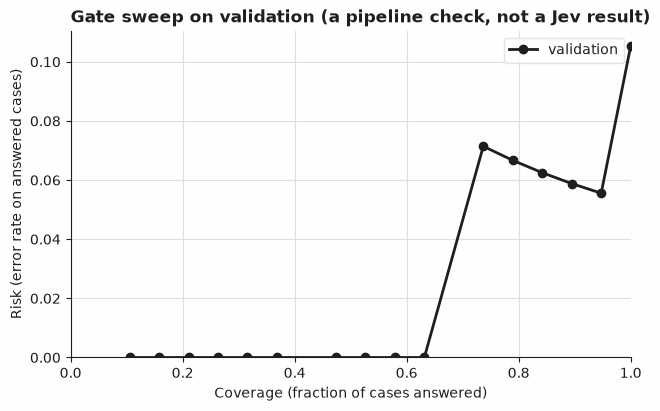

In [13]:
curve = selective_curve(val_correct, val_confidence)
for t, cov, acc, risk in zip(
    curve.thresholds, curve.coverage, curve.accuracy, curve.risk, strict=True
):
    chosen = "  <- frozen" if abs(t - threshold) < 1e-9 else ""
    print(
        f"threshold {t:.4f}  coverage {cov:.4f}  accuracy {acc:.4f}  risk {risk:.4f}{chosen}{selection}{check}"
    )
plot_risk_coverage(curve, label="validation", title=f"Gate sweep on validation{check}")

`0.4667` is the lowest of ten distinct thresholds on this sweep with zero risk: every one of the nine higher than it costs coverage for no gain in accuracy, which is exactly why `select_confidence_threshold` picks the lowest one. The first threshold with any risk at all sits one step below, at `0.44` (accuracy `0.9286`, one wrong validation answer let through); every threshold below that costs still more accuracy for still more coverage. This confidence-only coverage, `0.6316` at the frozen threshold, is higher than the outcomes-based coverage reported above (`0.5263`): the difference is exactly the confident `unverifiable` runs, which the gate alone would count as answered but `classify` sends to review regardless.

## What was and was not measured

Measured: that the pipeline runs end to end, and that the rule and the evaluation behave as designed on 38 scored runs (plus 2 more, shown in this notebook but never scored). Not measured: anything about how Jev performs, how fast it is, or what it costs. The stored answers in the offline run are written by hand as probabilities, some of them wrong on purpose, including one wrong *and* confident on `test` -- a false `complete` -- so every number above describes this fixture set and not a model.

In [14]:
if offline:
    print(f"Provenance: {backend.mode}. Not measured live: a pipeline check, not a Jev result.")
else:
    dates = ", ".join(getattr(backend, "recorded_dates", ()) or ()) or "this run"
    print(f"Provenance: {backend.mode}, model {backend.model}")
    print(f"Captured: {dates}")
    print(f"N: {len(val_examples)} validation and {len(test_examples)} test examples")

Provenance: synthetic. Not measured live: a pipeline check, not a Jev result.


## Next steps

- Add a hard tool-run record to `ROWS` in `build_fixtures.py` with the answer you expect a model might give, run `python build_fixtures.py`, and see where `classify` sends it.
- In the **Python's part** cell above, change `target_accuracy` from `1.0` to `0.9`: a lower bar admits more validation runs, including the one wrong answer this recipe pins the gate against, so the threshold and both splits' numbers move.
- Compare the action log between `validation` and `test` above: the same two actions split differently (4 handoffs to 6 retries on `validation`, 5 to 5 on `test`), and only `test`'s handoff count includes the costly mistake.
- Neighbouring recipes: [`10-answer-relevance-check`](../10-answer-relevance-check/) (`Noul`) judges whether a candidate response addresses the user's question, the same "does the evidence actually support what was claimed" question this recipe asks of a tool run instead of an answer; [`19-ci-failure-classification`](../19-ci-failure-classification/) (`Choice`) composes the same confidence-gate-then-workflow-table pattern over a different kind of recorded evidence; [`20-claim-support-classification`](../20-claim-support-classification/) (`Choice`) classifies whether a passage supports, contradicts, or leaves unresolved a claim -- the same three-way shape this recipe's `failed`/`complete`/`unverifiable` outcomes echo.